In [1]:
num_particles = 1
run_time_days = 100
time_step_minutes = 20
out_put_step_hours = 6

#initial position
# -49.91666793823242 -49.08333206176758 -0.08333330601453781 1.1665860414505005
# -49.75, -48.33,-0.17,1.33
lon0 = -49.916
lon1 = -49.083
lat0 = 1.166
lat1 = -0.0833

depth_min = 0 #todo: figure near-surface depths 
depth_max = 7

offset = 1
ref_date = "1993-01-01"
#reproducibility
rdm_seed = 67891
#paths
pathUVW= '/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW'
pathTS = "/work/bk1450/b383184/Amazon/Mercator/data/variables_c/tracers"
Hgr = "/work/bk1450/b383184/Amazon/Mercator/data/Hgr_cmesh.nc"
Zgr = "/work/bk1450/b383184/Amazon/Mercator/data/Zgr_cmesh2.nc"

In [2]:
# Parameters
offset = 4876
ref_date = "1993-01-01"
num_particles = 10000
run_time_days = 185


In [3]:
import numpy as np

In [4]:
out_path = f'../data/tracks_{rdm_seed}/' #path to store the particle zarr

start_time = np.datetime64(ref_date) + np.timedelta64(offset, "D")
start_time 

np.datetime64('2006-05-09')

In [5]:
import pandas as pd
start_time = pd.to_datetime(start_time)
t_plus_2y = start_time + pd.DateOffset(years=2)

st_yr = str(start_time)[0:4]
end_yr = str(t_plus_2y)[0:4]

print(st_yr)
print(end_yr)

2006
2008


## Particles from the Plume to the Atlantic

* Release particles from the plume every 5 days for 4 years (1993-1999)
* Release time 1993 to 2013
* Number of particles =  10_000
* Release depth = (0,7)
* Tracking salinity and temperature

In [6]:
from parcels import ParticleSet
from parcels import JITParticle
# from parcels import ScipyParticle
from parcels import AdvectionRK4_3D
from parcels import AdvectionRK4
from parcels import Variable
from datetime import timedelta
import numpy as np
from parcels import FieldSet
from glob import glob

In [7]:
np.random.seed(rdm_seed)

### MERCATOR (C grid)

In [8]:
from pathlib import Path
import os

def files_span(base, prefix, st_yr, end_yr, suffix='c.nc'):
    # all months from Jan st_yr to Dec end_yr
    months = pd.period_range(f'{st_yr}-01', f'{end_yr}-12', freq='M')
    pats = [Path(base) / f"{prefix}_{p.year}-{p.month:02d}{suffix}" for p in months]
    # keep only existing files
    return [str(p) for p in pats if p.exists()]

ufiles = files_span(pathUVW, 'U', st_yr, end_yr, 'c.nc')
vfiles = files_span(pathUVW, 'V', st_yr, end_yr, 'c.nc')
wfiles = files_span(pathUVW, 'W', st_yr, end_yr, 'fc.nc') 
tfiles = files_span(pathTS,  'T', st_yr, end_yr, 'c.nc')
sfiles = files_span(pathTS,  'S', st_yr, end_yr, 'c.nc')

In [9]:
# ufiles_1 = sorted(glob(f"{pathUVW}/U_{st_yr}*c.nc")) #start
# ufiles_2 = sorted(glob(f"{pathUVW}/U_{end_yr}*c.nc")) #end

# vfiles_1 = sorted(glob(f"{pathUVW}/V_{st_yr}*c.nc")) #start
# vfiles_2 = sorted(glob(f"{pathUVW}/V_{end_yr}*c.nc")) #end

# wfiles_1 = sorted(glob(f"{pathUVW}/W_{st_yr}*fc.nc"))
# wfiles_2 = sorted(glob(f"{pathUVW}/W_{end_yr}*fc.nc"))

# tfiles_1 = sorted(glob(f"{pathTS}/T_{st_yr}*c.nc"))
# tfiles_2 = sorted(glob(f"{pathTS}/T_{end_yr}*c.nc"))

# sfiles_1 = sorted(glob(f"{pathTS}/S_{st_yr}*c.nc"))
# sfiles_2 = sorted(glob(f"{pathTS}/S_{end_yr}*c.nc"))

# ufiles = np.unique(ufiles_1 + ufiles_2).tolist()
# ufiles

In [10]:
## define the fieldset
filenames = {
    "U": {
        "data":ufiles,
        "lon": Hgr,
        "lat": Hgr,
        "depth": wfiles[0],
    },
    
    "V": {
        "data": vfiles,
        "lon": Hgr,
        "lat": Hgr,
        "depth": wfiles[0],
    },
    
    "W": {
        "data": wfiles,
        "lon": Hgr,
        "lat": Hgr,
        "depth": wfiles[0],
    },

    "T": {
        "data": tfiles,
        "lon": Hgr,
        "lat": Hgr,
        "depth": wfiles[0], #Changed to Wfiles instead of tfiles
    },#on the t points

    "S": {
        "data": sfiles,
        "lon": Hgr,
        "lat": Hgr,
        "depth": wfiles[0], #Changed to Wfiles instead of tfiles
    }
}

variables = {
    "U": "vozocrtx",
    "V": "vomecrty",
    "W": "vovecrtz",
    "T": "votemper",
    "S": "vosaline",
}

interp_method = {
    "U":"cgrid_velocity",
    "V":"cgrid_velocity",
    "W":"cgrid_velocity",
    "T":"cgrid_velocity",
    "S":"cgrid_velocity",
}


dimensions = {
    "U": {"lon": "glamf", "lat": "gphif", "depth": "depthw", "time": "time_counter"},
    "V": {"lon": "glamf", "lat": "gphif", "depth": "depthw", "time": "time_counter"},
    "W": {"lon": "glamf", "lat": "gphif", "depth": "depthw", "time": "time_counter"},
    "T": {"lon": "glamf", "lat": "gphif", "depth": "depthw", "time": "time_counter"},
    "S": {"lon": "glamf", "lat": "gphif", "depth": "depthw", "time": "time_counter"},
}


## now the fieldset
fieldset = FieldSet.from_netcdf(
    filenames, 
    variables, 
    dimensions,
    interp_method = interp_method,
    mesh="spherical",
    # tracer_interp_method="cgrid_tracer",
    deferred_load=True,
    allow_time_extrapolation = False,
    gridindexingtype = "nemo",
)

In [11]:
start_pos_along_line = np.random.uniform(0,1,size=num_particles)
start_lon = lon0 + start_pos_along_line * (lon1-lon0)
start_lat = lat0 + start_pos_along_line * (lat1-lat0)
start_depth = np.random.uniform(depth_min,depth_max,size=num_particles)
start_times = np.datetime64(start_time)

In [12]:
def SampleTS(particle, fieldset, time):
    # z = particle.depth
    # Optional: clamp depth to tracer range if needed
    # zmin, zmax can be added as constants if you want; otherwise omit.
    particle.temp = fieldset.T[time, particle.depth, particle.lat, particle.lon]
    particle.sal  = fieldset.S[time, particle.depth, particle.lat, particle.lon]

In [13]:
class SampleParticle(JITParticle):
    """
    Add variables to the standard particle class.
    Sampling temperature, salinity and age of the particle.
    """

    temp = Variable("temp", dtype=np.float32,initial=np.nan)
    sal = Variable("sal", dtype=np.float32,initial=np.nan)
    # age = Variable("age", dtype=np.float32,initial=0.0)

In [14]:
# initiate pset
pset = ParticleSet(
    fieldset=fieldset,
    pclass = SampleParticle,
    lon = start_lon,
    lat = start_lat,
    depth=start_depth,
    time=start_times
) 

out_fn = f'Parcels_run_{rdm_seed}_{start_time}.zarr'

output_file = pset.ParticleFile(
    name=out_path+out_fn,
    outputdt=timedelta(hours=out_put_step_hours),
    chunks = (num_particles,int(run_time_days*24/out_put_step_hours/4))
)

In [15]:
##check the error
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

In [16]:
## Execute particles
pset.execute(
    [SampleTS,AdvectionRK4_3D,CheckError],
    runtime=timedelta(days=run_time_days),
    dt=timedelta(minutes=time_step_minutes),
    output_file= output_file
)

INFO: Output files are stored in ../data/tracks_67891/Parcels_run_67891_2006-05-09 00:00:00.zarr.


  0%|                                                                | 0/15984000.0 [00:00<?, ?it/s]

  0%|                                               | 1200.0/15984000.0 [00:07<26:50:02, 165.45it/s]

  0%|                                              | 21600.0/15984000.0 [00:08<1:17:22, 3438.26it/s]

  0%|                                              | 22800.0/15984000.0 [00:09<1:25:48, 3100.41it/s]

...

100%|██████████████████████████████████████████▉| 15942000.0/15984000.0 [1:23:16<00:19, 2127.47it/s]

100%|██████████████████████████████████████████▉| 15962400.0/15984000.0 [1:23:17<00:05, 3735.45it/s]

100%|██████████████████████████████████████████▉| 15963600.0/15984000.0 [1:23:18<00:05, 3432.09it/s]

100%|███████████████████████████████████████████| 15984000.0/15984000.0 [1:23:19<00:00, 5681.02it/s]

100%|███████████████████████████████████████████| 15984000.0/15984000.0 [1:23:19<00:00, 3197.15it/s]

### Plotting

In [17]:
import xarray as xr

In [18]:
out_path = f'../data/tracks_{rdm_seed}/'
# out_fn = 'Parcels_run_692' 

# ds_traj = xr.open_zarr(out_path+out_fn)
ds_traj = xr.open_zarr(out_path+out_fn)
# ds_traj = ds_traj.compute()
ds_traj = ds_traj.compute()
ds_traj

<xarray.Dataset> Size: 296MB
Dimensions:     (trajectory: 10000, obs: 740)
Coordinates:
  * obs         (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 733 734 735 736 737 738 739
  * trajectory  (trajectory) int64 80kB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float64 59MB 0.6044 0.612 ... 1.708 1.708
    lon         (trajectory, obs) float64 59MB -49.54 -49.54 ... -49.46 -49.46
    sal         (trajectory, obs) float32 30MB 0.2529 0.238 ... 2.725e-13
    temp        (trajectory, obs) float32 30MB 28.2 28.24 ... 3.086e-13
    time        (trajectory, obs) datetime64[ns] 59MB 2006-05-09 ... 2006-11-...
    z           (trajectory, obs) float64 59MB 4.414 4.479 4.545 ... 8.73 8.73
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

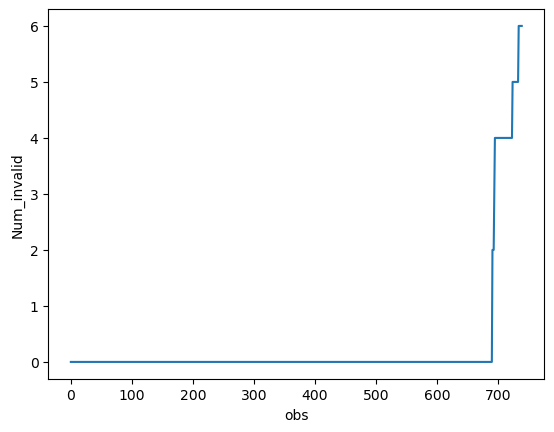

In [19]:
import matplotlib.pyplot as plt
ds_traj.lat.isnull().sum('trajectory').rename('Num_invalid').plot()
plt.show()

* Depths of 10m lead to unrealistic temperatures measurements (0-10 degrees)
* Depths of 7m give more realistic temperatures, less (0-10 degrees)